In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from xgboost import XGBRegressor

In [2]:
#!pip install pandas==1.5.3

In [3]:
#!pip install "xgboost<2.1"

In [4]:
df_train = pd.read_csv('me_dataset/raw_data_origami_TRAIN.csv',dtype='float32')
df_full = pd.read_csv('me_dataset/raw_data_origami_FULL.csv',dtype='float32')
df_test = pd.read_csv('me_dataset/raw_data_origami_HELDOUT.csv',dtype='float32')

In [5]:
df_train

,Temperature,MgCl2_concentration,pH_f,Incubation_time,DNase_I_concentration,Rectangles,Rods,Spheres,Diffusion_Coefficient
0,4.0,10.0,7.4,1440.0,0.0,0.0,1.0,0.0,2.320
1,4.0,10.0,7.4,1440.0,0.0,0.0,1.0,0.0,2.300
2,4.0,50.0,7.4,1440.0,0.0,0.0,1.0,0.0,2.220
3,4.0,10.0,7.4,1440.0,0.0,0.0,1.0,0.0,3.970
4,4.0,10.0,7.4,1440.0,0.0,0.0,1.0,0.0,4.290
...,...,...,...,...,...,...,...,...,...
1312,37.0,10.0,7.4,60.0,1.0,1.0,0.0,0.0,0.747
1313,37.0,10.0,7.4,60.0,5.0,1.0,0.0,0.0,0.312
1314,37.0,10.0,7.4,60.0,5.0,1.0,0.0,0.0,0.435
1315,37.0,10.0,7.4,60.0,5.0,1.0,0.0,0.0,0.512


In [6]:
X_columns=['Temperature','MgCl2_concentration','pH_f','Incubation_time','DNase_I_concentration','Rectangles','Rods','Spheres']
target='Diffusion_Coefficient'

In [7]:
X=df_train[X_columns]
y=df_train[target]
X_test=df_test[X_columns]
y_test=df_test[target]

In [8]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_s = scaler.fit_transform(X)
X_test_s = scaler.transform(X_test)
X_train = X_s
X_test = X_test_s
y_train = y

In [9]:
def build_rf():
    model = RandomForestRegressor(
        n_estimators=100,#50,
        max_depth=10,#20,
        min_samples_split=2,#2,
        min_samples_leaf=1,#1,
        random_state=42
    )
    return model

In [10]:
def build_svr():
    '''
    model = SVR(
        kernel='rbf',
        C=100,
        epsilon=1.0,
        gamma=1,
        degree=2
    '''
    model = SVR(
    kernel='rbf',
        C=0.1,
        epsilon=0.1,
        gamma=0.001,
        degree=4
    )
    return model

In [11]:
def build_gpr_1k():
    kernel = ConstantKernel(1.0) * RBF(length_scale=10) + WhiteKernel(noise_level=1.0)#0.25)
    
    model = GaussianProcessRegressor(
        kernel=kernel,
        alpha=0.001,#1e-7,
        normalize_y=True
    )
    return model

In [12]:
def build_gpr_2k():
    kernel = ConstantKernel(1.0) * (
        RBF(length_scale=1) + RBF(length_scale=0.001)
    ) + WhiteKernel(noise_level=0.25)

    model = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-7,
        normalize_y=True
    )
    return model

In [13]:
def build_xgb():
    model = XGBRegressor(
        n_estimators=25,
        max_depth=3,
        learning_rate=0.4,
        subsample=0.8,
        colsample_bytree=0.6,
        random_state=42
    )
    return model

In [14]:
def predict_consensus(rf, gpr, X):
    return 0.5 * rf.predict(X) + 0.5 * gpr.predict(X)

In [15]:
def train_and_predict(model, X_train, y_train, X_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return y_pred

In [16]:
from sklearn.metrics import mean_squared_error
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [17]:
# build models
rf = build_rf()
svr = build_svr()
gpr1 = build_gpr_1k()
gpr2 = build_gpr_2k()
xgb = build_xgb()

# train
rf.fit(X_train, y_train)
svr.fit(X_train, y_train)
gpr1.fit(X_train, y_train)
gpr2.fit(X_train, y_train)
xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# One time training example, not used in actual experiments

# training set

In [97]:
# predict
pred_rf = rf.predict(X_train)
pred_svr = svr.predict(X_train)
pred_gpr1 = gpr1.predict(X_train)
pred_gpr2 = gpr2.predict(X_train)
pred_xgb = xgb.predict(X_train)

# consensus
pred_cons = 0.5 * (pred_rf + pred_gpr2)

# evaluate
print("RF:", rmse(y_train, pred_rf))
print("SVR:", rmse(y_train, pred_svr))
print("GPR-1k:", rmse(y_train, pred_gpr1))
print("GPR-2k:", rmse(y_train, pred_gpr2))
print("XGB:", rmse(y_train, pred_xgb))
print("CONS:", rmse(y_train, pred_cons))

RF: 0.6202604848252212
SVR: 1.3684589807310703
GPR-1k: 0.500421626211149
GPR-2k: 0.5021581246755994
XGB: 0.8230777816147512
CONS: 0.5412775002726947


# validation set

In [98]:
# predict
pred_rf = rf.predict(X_val)
pred_svr = svr.predict(X_val)
pred_gpr1 = gpr1.predict(X_val)
pred_gpr2 = gpr2.predict(X_val)
pred_xgb = xgb.predict(X_val)

# consensus
pred_cons = 0.5 * (pred_rf + pred_gpr2)

# evaluate
print("RF:", rmse(y_val, pred_rf))
print("SVR:", rmse(y_val, pred_svr))
print("GPR-1k:", rmse(y_val, pred_gpr1))
print("GPR-2k:", rmse(y_val, pred_gpr2))
print("XGB:", rmse(y_val, pred_xgb))
print("CONS:", rmse(y_val, pred_cons))

RF: 2.826828640791901
SVR: 1.4442712636142732
GPR-1k: 1.4446361283166247
GPR-2k: 1.4446361283166247
XGB: 1.5623509145183856
CONS: 1.8783623956995268


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GaussianProcessRegressor was fitted without feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GaussianProcessRegressor was fitted without feature names
  warnings.warn(


# held out set test

In [24]:
# predict
pred_rf = rf.predict(X_test)
pred_svr = svr.predict(X_test)
pred_gpr1 = gpr1.predict(X_test)
pred_gpr2 = gpr2.predict(X_test)
pred_xgb = xgb.predict(X_test)

# consensus
pred_cons = 0.5 * (pred_rf + pred_gpr2)

# evaluate
print("RF:", rmse(y_test, pred_rf))
print("SVR:", rmse(y_test, pred_svr))
print("GPR-1k:", rmse(y_test, pred_gpr1))
print("GPR-2k:", rmse(y_test, pred_gpr2))
print("XGB:", rmse(y_test, pred_xgb))
print("CONS:", rmse(y_test, pred_cons))

RF: 0.5598088937061376
SVR: 1.4081538205616817
GPR-1k: 0.3852548230509388
GPR-2k: 0.35140387903528525
XGB: 0.7615508065560607
CONS: 0.42938645712828843


# Parameter search

In [18]:
from sklearn.model_selection import GridSearchCV
def run_grid_search(model, param_grid, X_train, y_train):
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,  
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)
    print("Best params:", grid.best_params_)
    print("Best RMSE:", (-grid.best_score_)**0.5)
    return grid.best_estimator_

In [100]:
rf_model = RandomForestRegressor(random_state=42)
rf_param_grid = {
    "n_estimators": [25, 50, 100, 200],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8]
}
best_rf = run_grid_search(rf_model, rf_param_grid, X, y)

Fitting 5 folds for each of 320 candidates, totalling 1600 fits
Best params: {'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 20, 'n_estimators': 100}
Best RMSE: 1.6299189498928743


In [23]:
svr_model = SVR()
svr_param_grid = {
    "C": [0.1, 1.0, 10, 100],
    "epsilon": [0.01, 0.1, 0.5, 1.0],
    "kernel": ["linear", "poly", "rbf", "sigmoid"],
    "degree": [2, 3, 4],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1]
}
best_svr = run_grid_search(svr_model, svr_param_grid, X, y)

Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
Best params: {'C': 0.1, 'degree': 4, 'epsilon': 0.1, 'gamma': 0.001, 'kernel': 'poly'}
Best RMSE: 1.4223984028531151


In [24]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
import itertools
def grid_search_gpr_1k(X_train, y_train):
    best_model = None
    best_score = float("inf")
    best_para = None
    length_scales = [10, 5, 1.0, 0.1, 0.01, 0.001]
    noise_levels = [1.0, 0.5, 0.25, 0.1]
    alphas = [1e-3, 1e-5, 1e-7, 1e-9]
    for l, n, a in itertools.product(length_scales, noise_levels, alphas):
        kernel = ConstantKernel(1.0) * RBF(length_scale=l) + WhiteKernel(noise_level=n)
        model = GaussianProcessRegressor(
            kernel=kernel,
            alpha=a,
            normalize_y=True
        )
        model.fit(X_train, y_train)
        pred = model.predict(X_train)
        rmse = np.sqrt(((pred - y_train)**2).mean())
        if rmse < best_score:
            best_score = rmse
            best_model = model
            best_para = (l , n , a)
    print("Best GPR-1k RMSE:", best_score)
    print("Best GPR-1k params:", best_para)
    return best_model, best_para
def grid_search_gpr_2k(X_train, y_train):
    best_model = None
    best_score = float("inf")
    best_para = None
    length_scale_1 = [10, 5, 1.0, 0.1]
    length_scale_2 = [0.01, 0.001, 0.0001]
    noise_levels = [1.0, 0.5, 0.25, 0.1]
    alphas = [1e-3, 1e-5, 1e-7, 1e-9]
    for l1, l2, n, a in itertools.product(length_scale_1, length_scale_2, noise_levels, alphas):
        kernel = ConstantKernel(1.0) * (
            RBF(length_scale=l1) + RBF(length_scale=l2)
        ) + WhiteKernel(noise_level=n)
        model = GaussianProcessRegressor(
            kernel=kernel,
            alpha=a,
            normalize_y=True
        )
        model.fit(X_train, y_train)
        pred = model.predict(X_train)        
        rmse = np.sqrt(((pred - y_train)**2).mean())
        if rmse < best_score:
            best_score = rmse
            best_model = model
            best_para = ( l1 , l2 , n , a )
    print("Best GPR-2k RMSE:", best_score)
    print("Best GPR-2k params:", best_para)
    return best_model, best_para

In [25]:
xgb_model = XGBRegressor(random_state=42)
xgb_param_grid = {
    "n_estimators": [25, 50, 100, 200],
    "max_depth": [3, 6, 9, 12],
    "learning_rate": [0.4, 0.6, 0.8, 1.0],
    "subsample": [0.4, 0.6, 0.8, 1.0],
    "colsample_bytree": [0.4, 0.6, 0.8, 1.0]
}
best_xgb = run_grid_search(xgb_model, xgb_param_grid, X, y)

Fitting 5 folds for each of 1024 candidates, totalling 5120 fits
Best params: {'colsample_bytree': 0.6, 'learning_rate': 0.4, 'max_depth': 3, 'n_estimators': 25, 'subsample': 0.8}
Best RMSE: 1.5506406014029293


In [26]:
gpr_1k_best, best_para1=grid_search_gpr_1k(X, y)
gpr_2k_best, best_para2=grid_search_gpr_2k(X, y)

/home/users/jl1417/.local/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 19 iteration(s) (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/home/users/jl1417/.local/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 24 iteration(s) (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/home/users/jl1417/.local/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again 

Best GPR-1k RMSE: 0.500421621486362
Best GPR-1k params: (10, 1.0, 0.001)


/home/users/jl1417/.local/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/jl1417/.local/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 18 iteration(s) (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/home/users/jl1417/.local/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnin

Best GPR-2k RMSE: 0.502151373621176
Best GPR-2k params: (1.0, 0.001, 0.25, 1e-07)


# new experiments

In [18]:
df_new = pd.read_csv('me_dataset/new_experiments_df.csv',dtype='float32')

In [19]:
X_new=df_new[X_columns]
y_new=df_new[target]
X_new_s=scaler.transform(X_new)
X_new=X_new_s

# new set

In [21]:
# predict
pred_rf = rf.predict(X_new)
pred_svr = svr.predict(X_new)
pred_gpr1 = gpr1.predict(X_new)
pred_gpr2 = gpr2.predict(X_new)
pred_xgb = xgb.predict(X_new)

# consensus
pred_cons = 0.5 * (pred_rf + pred_gpr2)

# evaluate
print("RF:", rmse(y_new, pred_rf))
print("GPR-2k:", rmse(y_new, pred_gpr2))
print("XGB:", rmse(y_new, pred_xgb))
print("CONS:", rmse(y_new, pred_cons))

RF: 1.511730116372784
GPR-2k: 0.9047072579104931
XGB: 1.6130784763986246
CONS: 1.0000600016056405


In [22]:
df_new

,Temperature,MgCl2_concentration,pH_f,Incubation_time,DNase_I_concentration,Rectangles,Rods,Spheres,Diffusion_Coefficient
0,36.0,0.70,7.35,80.0,0.2,0.0,1.0,0.0,3.27
1,36.0,0.70,7.35,80.0,0.2,0.0,1.0,0.0,3.19
2,36.0,0.70,7.35,80.0,0.2,0.0,1.0,0.0,3.48
3,36.0,0.70,7.35,80.0,0.2,0.0,0.0,1.0,2.72
4,36.0,0.70,7.35,80.0,0.2,0.0,0.0,1.0,2.70
...,...,...,...,...,...,...,...,...,...
76,36.0,0.85,2.30,65.0,0.2,0.0,0.0,1.0,1.95
77,36.0,0.85,2.30,65.0,0.2,0.0,0.0,1.0,2.47
78,36.0,0.85,2.30,65.0,0.2,1.0,0.0,0.0,1.01
79,36.0,0.85,2.30,65.0,0.2,1.0,0.0,0.0,1.05


In [23]:
df_rods=df_test[df_test['Rods']==1]
df_spheres=df_test[df_test['Spheres']==1]
df_rect=df_test[df_test['Rectangles']==1]

In [26]:
X_ho_rods=df_rods[X_columns]
y_ho_rods=df_rods[target]
X_ho_spheres=df_spheres[X_columns]
y_ho_spheres=df_spheres[target]
X_ho_rect=df_rect[X_columns]
y_ho_rect=df_rect[target]

X_ho_rods_s=scaler.transform(X_ho_rods)
X_ho_rods=X_ho_rods_s
X_ho_spheres_s=scaler.transform(X_ho_spheres)
X_ho_spheres=X_ho_spheres_s
X_ho_rect_s=scaler.transform(X_ho_rect)
X_ho_rect=X_ho_rect_s

In [27]:
pred_gpr2_ho_rods = gpr2.predict(X_ho_rods)
pred_gpr2_ho_spheres = gpr2.predict(X_ho_spheres)
pred_gpr2_ho_rect = gpr2.predict(X_ho_rect)

In [28]:
def plot_figure4c(y_true1, y_true2, y_pred1, y_pred2, title="Figure 4c: Predicted vs Actual",name='figure4c.png'):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true1, y_pred1, alpha=0.6, label="Prospective Set")

    plt.scatter(y_true2, y_pred2, alpha=0.6, label="Held out Set")

    min_val = 0
    max_val = 6
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
    
    plt.xlabel("Actual Diffusion Coefficient")
    plt.ylabel("Predicted Diffusion Coefficient")
    plt.title(title)
    plt.legend()   
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(name, dpi=300, bbox_inches='tight')
    plt.show()
    

In [29]:
y_ho_rods = np.array(y_ho_rods).ravel()
y_ho_spheres = np.array(y_ho_spheres).ravel()
y_ho_rect = np.array(y_ho_rect).ravel()

In [30]:
df_rods_new=df_new[df_new['Rods']==1]
df_spheres_new=df_new[df_new['Spheres']==1]
df_rect_new=df_new[df_new['Rectangles']==1]

X_new_rods=df_rods_new[X_columns]
y_new_rods=df_rods_new[target]
X_new_spheres=df_spheres_new[X_columns]
y_new_spheres=df_spheres_new[target]
X_new_rect=df_rect_new[X_columns]
y_new_rect=df_rect_new[target]

y_new_rods = np.array(y_new_rods).ravel()
y_new_spheres = np.array(y_new_spheres).ravel()
y_new_rect = np.array(y_new_rect).ravel()

X_new_rods_s=scaler.transform(X_new_rods)
X_new_rods=X_new_rods_s
X_new_spheres_s=scaler.transform(X_new_spheres)
X_new_spheres=X_new_spheres_s
X_new_rect_s=scaler.transform(X_new_rect)
X_new_rect=X_new_rect_s

pred_gpr2_new_rods = gpr2.predict(X_new_rods)
pred_gpr2_new_spheres = gpr2.predict(X_new_spheres)
pred_gpr2_new_rect = gpr2.predict(X_new_rect)

# rods

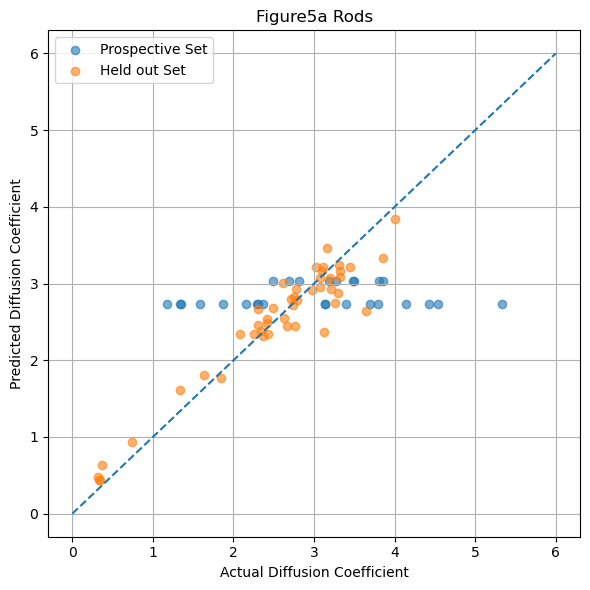

In [31]:
plot_figure4c(y_new_rods ,y_ho_rods, np.array(pred_gpr2_new_rods).ravel(),np.array(pred_gpr2_ho_rods).ravel(),"Figure5a Rods","figure5a rods.png")

# rectangle

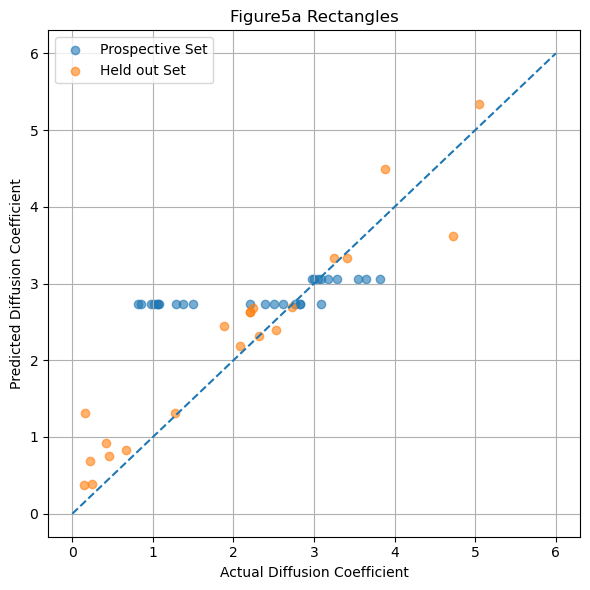

In [32]:
plot_figure4c(y_new_rect ,y_ho_rect, np.array(pred_gpr2_new_rect).ravel(),np.array(pred_gpr2_ho_rect).ravel(),"Figure5a Rectangles","figure5a rect.png")

# spheres

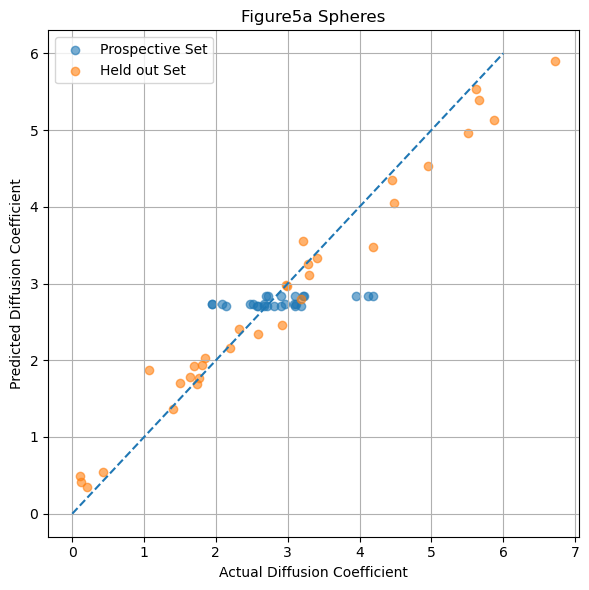

In [33]:
plot_figure4c(y_new_spheres ,y_ho_spheres, np.array(pred_gpr2_new_spheres).ravel(),np.array(pred_gpr2_ho_spheres).ravel(),"Figure5a Spheres","figure5a spheres.png")

# NNs

In [54]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1) 
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)  
        return x

In [55]:
class NNs(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.fc4 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.2)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.fc4(x)  
        return x

In [56]:
model = NNs()
criterion = nn.MSELoss()           
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)#,weight_decay=1e-5)

In [172]:
from torch.utils.data import TensorDataset, DataLoader
import torch
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)
dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(
    dataset,
    batch_size=32,   
    shuffle=True   
)

In [173]:
def train(model, loader, optimizer, criterion, epochs=100):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in loader: 
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch+1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}")

In [179]:
train(model, loader,optimizer, criterion, epochs=300)

/usr/pkg/miniconda-23.9.0/lib/python3.11/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/pkg/miniconda-23.9.0/lib/python3.11/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([5])) that is different to the input size (torch.Size([5, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/300], Loss: 156.5063
Epoch [20/300], Loss: 138.4890
Epoch [30/300], Loss: 125.9353
Epoch [40/300], Loss: 116.9015
Epoch [50/300], Loss: 110.3505
Epoch [60/300], Loss: 100.0055
Epoch [70/300], Loss: 93.4120
Epoch [80/300], Loss: 87.8886
Epoch [90/300], Loss: 88.1472
Epoch [100/300], Loss: 82.2675
Epoch [110/300], Loss: 82.2960
Epoch [120/300], Loss: 80.1433
Epoch [130/300], Loss: 80.2143
Epoch [140/300], Loss: 79.7222
Epoch [150/300], Loss: 79.1396
Epoch [160/300], Loss: 78.5691
Epoch [170/300], Loss: 79.4661
Epoch [180/300], Loss: 80.7275
Epoch [190/300], Loss: 81.6659
Epoch [200/300], Loss: 80.4096
Epoch [210/300], Loss: 78.7431
Epoch [220/300], Loss: 79.2607
Epoch [230/300], Loss: 80.4663
Epoch [240/300], Loss: 80.2251
Epoch [250/300], Loss: 79.6657
Epoch [260/300], Loss: 82.2575
Epoch [270/300], Loss: 79.3042
Epoch [280/300], Loss: 78.1989
Epoch [290/300], Loss: 79.2493
Epoch [300/300], Loss: 80.5563


In [180]:
model.eval() 
with torch.no_grad():  
    y_pred = model(torch.tensor(X_train, dtype=torch.float32))
y_pred = y_pred.cpu().numpy()
print("NN:", rmse(y_train, y_pred))

NN: 1.3424024700633115


In [181]:
model.eval() 
with torch.no_grad():  
    y_pred = model(torch.tensor(X_val, dtype=torch.float32))
y_pred = y_pred.cpu().numpy()
print("NN:", rmse(y_val, y_pred))

NN: 1.4426095793306188


In [182]:
model.eval() 
with torch.no_grad():  
    y_pred = model(torch.tensor(X_test, dtype=torch.float32))
y_pred = y_pred.cpu().numpy()
print("NN:", rmse(y_test, y_pred))

NN: 1.3846057966401624


In [183]:
model.eval() 
with torch.no_grad():  
    y_pred = model(torch.tensor(X_new, dtype=torch.float32))
y_pred = y_pred.cpu().numpy()
print("NN:", rmse(y_new, y_pred))

NN: 0.9403786967269644


# variantion analysis

In [37]:
from sklearn.model_selection import train_test_split
rmse_rf=[]
rmse_svr=[]
rmse_1k=[]
rmse_2k=[]
rmse_xgb=[]
rmse_cons=[]

rmse_rf2=[]
rmse_svr2=[]
rmse_1k2=[]
rmse_2k2=[]
rmse_xgb2=[]
rmse_cons2=[]

In [38]:
for i in range (5):
    X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,      
    random_state=(i+1)*42,    
    shuffle=True      
)
    rf = build_rf()
    svr = build_svr()
    gpr1 = build_gpr_1k()
    gpr2 = build_gpr_2k()
    xgb = build_xgb()
    rf.fit(X_train, y_train)
    svr.fit(X_train, y_train)
    gpr1.fit(X_train, y_train)
    gpr2.fit(X_train, y_train)
    xgb.fit(X_train, y_train)
    pred_rf = rf.predict(X_train)
    pred_svr = svr.predict(X_train)
    pred_gpr1 = gpr1.predict(X_train)
    pred_gpr2 = gpr2.predict(X_train)
    pred_xgb = xgb.predict(X_train)
    pred_cons = 0.5 * (pred_rf + pred_gpr2)
    rmse_rf.append(rmse(y_train, pred_rf))
    rmse_svr.append(rmse(y_train, pred_svr))
    rmse_1k.append(rmse(y_train, pred_gpr1))
    rmse_2k.append(rmse(y_train, pred_gpr2))
    rmse_xgb.append(rmse(y_train, pred_xgb))
    rmse_cons.append(rmse(y_train, pred_cons))
    
    pred_rf = rf.predict(X_val)
    pred_svr = svr.predict(X_val)
    pred_gpr1 = gpr1.predict(X_val)
    pred_gpr2 = gpr2.predict(X_val)
    pred_xgb = xgb.predict(X_val)
    pred_cons = 0.5 * (pred_rf + pred_gpr2)
    rmse_rf2.append(rmse(y_val, pred_rf))
    rmse_svr2.append(rmse(y_val, pred_svr))
    rmse_1k2.append(rmse(y_val, pred_gpr1))
    rmse_2k2.append(rmse(y_val, pred_gpr2))
    rmse_xgb2.append(rmse(y_val, pred_xgb))
    rmse_cons2.append(rmse(y_val, pred_cons))

# training set

In [39]:
print("RF:", rmse_rf)
print("SVR:",rmse_svr)
print("GPR-1k:", rmse_1k)
print("GPR-2k:", rmse_2k)
print("XGB:", rmse_xgb)
print("CONS:",rmse_cons)

RF: [np.float64(0.5807891766570864), np.float64(0.6083357467020684), np.float64(0.6195873652430096), np.float64(0.6111075443852454), np.float64(0.6066031799370944)]
SVR: [np.float64(1.3324718941528857), np.float64(1.3396975164548364), np.float64(1.3364080984979876), np.float64(1.3318241952535699), np.float64(1.3086191194164578)]
GPR-1k: [np.float64(0.46639742966579556), np.float64(0.5037198656360373), np.float64(0.6185836749278719), np.float64(0.5953438889111587), np.float64(0.5876509455522817)]
GPR-2k: [np.float64(0.4686329702433068), np.float64(0.5059026854027506), np.float64(0.5090383207295599), np.float64(0.4757006820981109), np.float64(0.49760683597070754)]
XGB: [np.float64(0.7928909864959509), np.float64(0.8182915998630705), np.float64(0.834573434957336), np.float64(0.8065947734372102), np.float64(0.7867197061360524)]
CONS: [np.float64(0.5045371528281889), np.float64(0.5398012328191802), np.float64(0.5458481825147197), np.float64(0.5213808852724605), np.float64(0.5327174376739806

In [40]:
print("RF: ")
print('mean: ',np.mean(rmse_rf), ' std: ',np.std(rmse_rf))
print("SVR: ")
print('mean: ',np.mean(rmse_svr), ' std: ',np.std(rmse_svr))
print("GPR-1k: ")
print('mean: ',np.mean(rmse_1k), ' std: ',np.std(rmse_1k))
print("GPR-2k: ")
print('mean: ',np.mean(rmse_2k), ' std: ',np.std(rmse_2k))
print("XGB: ")
print('mean: ',np.mean(rmse_xgb), ' std: ',np.std(rmse_xgb))
print("CONS: ")
print('mean: ',np.mean(rmse_cons), ' std: ',np.std(rmse_cons))

RF: 
mean:  0.6052846025849008  std:  0.013034950624431826
SVR: 
mean:  1.3298041647551475  std:  0.010968079121614772
GPR-1k: 
mean:  0.554339160938629  std:  0.05867619865696109
GPR-2k: 
mean:  0.4913762988888871  std:  0.016277385985658983
XGB: 
mean:  0.807814100177924  std:  0.017291613789050222
CONS: 
mean:  0.528856978221706  std:  0.014633705970538263


# validation set

In [41]:
print("RF:", rmse_rf2)
print("SVR:",rmse_svr2)
print("GPR-1k:", rmse_1k2)
print("GPR-2k:", rmse_2k2)
print("XGB:", rmse_xgb2)
print("CONS:",rmse_cons2)

RF: [np.float64(0.8002628260493961), np.float64(0.6948027519257417), np.float64(0.7184387160367051), np.float64(0.7703936696341703), np.float64(0.7817710984015295)]
SVR: [np.float64(1.3628340397086933), np.float64(1.3507952648766142), np.float64(1.3568033780737934), np.float64(1.3598821649032395), np.float64(1.41708126458534)]
GPR-1k: [np.float64(0.7179127710938191), np.float64(0.7432346332392582), np.float64(0.756663468508451), np.float64(0.8180086746451408), np.float64(0.8411488811211145)]
GPR-2k: [np.float64(0.7190316468929013), np.float64(0.6627076093448109), np.float64(0.6877538983918269), np.float64(0.7358339589521643), np.float64(0.7483422878272292)]
XGB: [np.float64(0.9574127059864782), np.float64(0.86850281361688), np.float64(0.8755352222562062), np.float64(0.9373779217391791), np.float64(0.9561092684540425)]
CONS: [np.float64(0.7397654572407389), np.float64(0.6338707645709276), np.float64(0.6684051037216614), np.float64(0.7312511648398464), np.float64(0.7383113936730914)]


In [42]:
print("RF: ")
print('mean: ',np.mean(rmse_rf2), ' std: ',np.std(rmse_rf2))
print("SVR: ")
print('mean: ',np.mean(rmse_svr2), ' std: ',np.std(rmse_svr2))
print("GPR-1k: ")
print('mean: ',np.mean(rmse_1k2), ' std: ',np.std(rmse_1k2))
print("GPR-2k: ")
print('mean: ',np.mean(rmse_2k2), ' std: ',np.std(rmse_2k2))
print("XGB: ")
print('mean: ',np.mean(rmse_xgb2), ' std: ',np.std(rmse_xgb2))
print("CONS: ")
print('mean: ',np.mean(rmse_cons2), ' std: ',np.std(rmse_cons2))

RF: 
mean:  0.7531338124095085  std:  0.039863274016448284
SVR: 
mean:  1.369479222429536  std:  0.02413289739724494
GPR-1k: 
mean:  0.7753936857215568  std:  0.04653786467564199
GPR-2k: 
mean:  0.7107338802817865  std:  0.031457468003227664
XGB: 
mean:  0.9189875864105572  std:  0.03906285642472181
CONS: 
mean:  0.7023207768092532  std:  0.04328989028137562


# prediction

In [25]:
df_realm = pd.read_csv('me_dataset/datas.csv',dtype='float32')

In [26]:
value_lists = []
for col in df_realm.columns:
    values = df_realm[col].dropna().unique()
    value_lists.append(values)

In [27]:
import itertools
grid = list(itertools.product(*value_lists))

In [28]:
grid_df = pd.DataFrame(grid, columns=df_realm.columns)

In [29]:
onehots = pd.DataFrame([
    [1,0,0],
    [0,1,0],
    [0,0,1]
], columns=["Rods","Spheres","Rectangles"])
df_expanded = grid_df.merge(onehots, how="cross")

In [30]:
df_expanded

,Temperature,MgCl2_concentration,pH_f,Incubation_time,DNase_I_concentration,Rods,Spheres,Rectangles
0,4.0,0.18,5.34,15.0,0.0,1,0,0
1,4.0,0.18,5.34,15.0,0.0,0,1,0
2,4.0,0.18,5.34,15.0,0.0,0,0,1
3,4.0,0.18,5.34,15.0,0.2,1,0,0
4,4.0,0.18,5.34,15.0,0.2,0,1,0
...,...,...,...,...,...,...,...,...
942475,50.0,30.00,10.30,1440.0,1.0,0,1,0
942476,50.0,30.00,10.30,1440.0,1.0,0,0,1
942477,50.0,30.00,10.30,1440.0,5.0,1,0,0
942478,50.0,30.00,10.30,1440.0,5.0,0,1,0


In [31]:
X_grid=df_expanded[X_columns]
X_grid_s=scaler.transform(X_grid)
X_grid=X_grid_s

In [32]:
df_Rods=df_expanded[df_expanded['Rods']==1]
df_Spheres=df_expanded[df_expanded['Spheres']==1]
df_Rectangles=df_expanded[df_expanded['Rectangles']==1]

In [33]:
X_grid_Rods=df_Rods[X_columns]
X_grid_s_Rods=scaler.transform(X_grid_Rods)
X_grid_Rods=X_grid_s_Rods

X_grid_Spheres=df_Spheres[X_columns]
X_grid_s_Spheres=scaler.transform(X_grid_Spheres)
X_grid_Spheres=X_grid_s_Spheres

X_grid_Rectangles=df_Rectangles[X_columns]
X_grid_s_Rectangles=scaler.transform(X_grid_Rectangles)
X_grid_Rectangles=X_grid_s_Rectangles

In [34]:
final_rods=gpr2.predict(X_grid_Rods)
print(final_rods)

[2.73914289 2.73914289 2.73914289 ... 2.73914289 2.73914289 2.73914289]


In [35]:
final_spheres=gpr2.predict(X_grid_Spheres)
print(final_spheres)

[2.73914289 2.73914289 2.73914289 ... 2.73914289 2.73914289 2.73914289]


In [36]:
final_rectangles=gpr2.predict(X_grid_Rectangles)
print(final_rectangles)

[2.73914289 2.73914289 2.73914289 ... 2.73914289 2.73914289 2.73914289]


# metric definition

In [37]:
df_train_rods=df_train[df_train['Rods']==1]
df_train_spheres=df_train[df_train['Spheres']==1]
df_train_rects=df_train[df_train['Rectangles']==1]

In [38]:
y_max_rods=np.max(df_train_rods[target])
y_min_rods=np.min(df_train_rods[target])

y_max_spheres=np.max(df_train_spheres[target])
y_min_spheres=np.min(df_train_spheres[target])

y_max_rects=np.max(df_train_rects[target])
y_min_rects=np.min(df_train_rects[target])
print('rods: ',y_min_rods,' - ',y_max_rods)
print('spheres: ',y_min_spheres,' - ',y_max_spheres)
print('rectangles: ',y_min_rects,' - ',y_max_rects)

rods:  0.11100000143051147  -  4.940000057220459
spheres:  0.11100000143051147  -  7.119999885559082
rectangles:  0.13500000536441803  -  5.940000057220459


In [39]:
y_max_rods=min(53.5,y_max_rods)
y_min_rods=max(0.535,y_min_rods)

y_max_spheres=min(45,y_max_spheres)
y_min_spheres=max(0.45,y_min_spheres)

y_max_rects=min(33.3,y_max_rects)
y_min_rects=max(0.332,y_min_rects)
print('rods: ',y_min_rods,' - ',y_max_rods)
print('spheres: ',y_min_spheres,' - ',y_max_spheres)
print('rectangles: ',y_min_rects,' - ',y_max_rects)

rods:  0.535  -  4.940000057220459
spheres:  0.45  -  7.119999885559082
rectangles:  0.332  -  5.940000057220459


In [40]:
d0_rods=(5.35-y_min_rods)/(y_max_rods-y_min_rods)
d0_spheres=(4.5-y_min_spheres)/(y_max_spheres-y_min_spheres)
d0_rects=(3.33-y_min_rects)/(y_max_rects-y_min_rects)

final_rods =abs( (final_rods-y_min_rods)/(y_max_rods-y_min_rods)-d0_rods)
final_spheres = abs((final_spheres-y_min_spheres)/(y_max_spheres-y_min_spheres)-d0_spheres)
final_rectangles =abs( (final_rectangles-y_min_rects)/(y_max_rects-y_min_rects)-d0_rects)

In [41]:
print(final_rods)
print(final_spheres)
print(final_rectangles)

[0.59270308 0.59270308 0.59270308 ... 0.59270308 0.59270308 0.59270308]
[0.26399657 0.26399657 0.26399657 ... 0.26399657 0.26399657 0.26399657]
[0.10535968 0.10535968 0.10535968 ... 0.10535968 0.10535968 0.10535968]


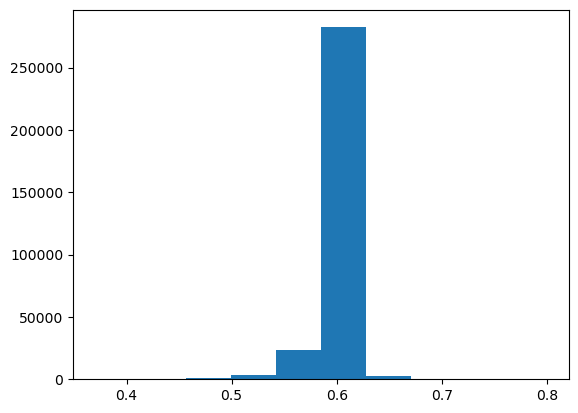

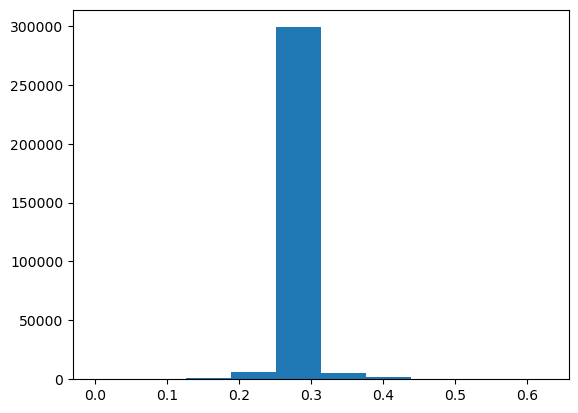

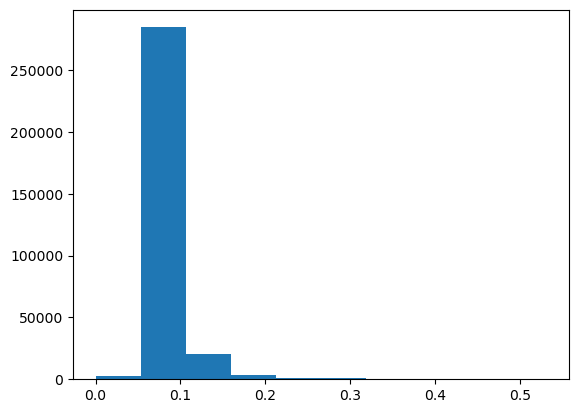

In [42]:
plt.hist(final_rods)
plt.show()
plt.hist(final_spheres)
plt.show()
plt.hist(final_rectangles)
plt.show()

In [43]:
df_Rods['metric']=final_rods
df_Spheres['metric']=final_spheres
df_Rectangles['metric']=final_rectangles

C:\Users\ljq\AppData\Local\Temp\ipykernel_21392\3185904168.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Rods['metric']=final_rods
C:\Users\ljq\AppData\Local\Temp\ipykernel_21392\3185904168.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Spheres['metric']=final_spheres
C:\Users\ljq\AppData\Local\Temp\ipykernel_21392\3185904168.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

In [44]:
df_Rods.loc[df_Rods["metric"].abs().idxmin()]

Temperature              37.000000
MgCl2_concentration       2.000000
pH_f                      7.410000
Incubation_time          60.000000
DNase_I_concentration     0.000000
Rods                      1.000000
Spheres                   0.000000
Rectangles                0.000000
metric                    0.370402
Name: 589968, dtype: float64

In [45]:
df_Spheres.loc[df_Spheres["metric"].abs().idxmin()]

Temperature              37.000000
MgCl2_concentration       1.000000
pH_f                      7.330000
Incubation_time          60.000000
DNase_I_concentration     0.000000
Rods                      0.000000
Spheres                   1.000000
Rectangles                0.000000
metric                    0.000038
Name: 580393, dtype: float64

In [46]:
df_Rectangles.loc[df_Rectangles["metric"].abs().idxmin()]

Temperature              35.00000
MgCl2_concentration       0.18000
pH_f                      7.37000
Incubation_time          60.00000
DNase_I_concentration     0.00000
Rods                      0.00000
Spheres                   0.00000
Rectangles                1.00000
metric                    0.00001
Name: 478082, dtype: float64

In [47]:
df_Rods.to_csv("df_rods.csv", index=False)
df_Spheres.to_csv("df_spheres.csv", index=False)
df_Rectangles.to_csv("df_rects.csv", index=False)

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
def plot_heatmap_2d(df, x_col, y_col, metric_col="metric"):
    pivot = df.pivot_table(
        index=y_col,
        columns=x_col,
        values=metric_col,
        aggfunc="mean"  
    )
    pivot = pivot.sort_index().sort_index(axis=1)
    plt.figure(figsize=(6,5))
    plt.imshow(pivot, aspect='auto', origin='lower')
    plt.colorbar(label="metric (smaller is better)")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{metric_col} over {x_col}-{y_col}")
    plt.tight_layout()
    plt.show()

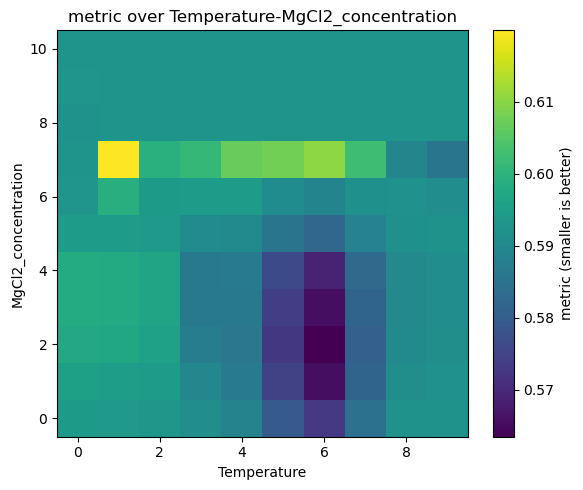

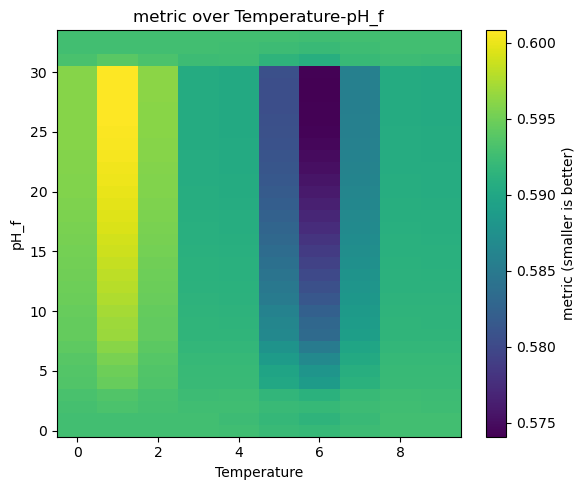

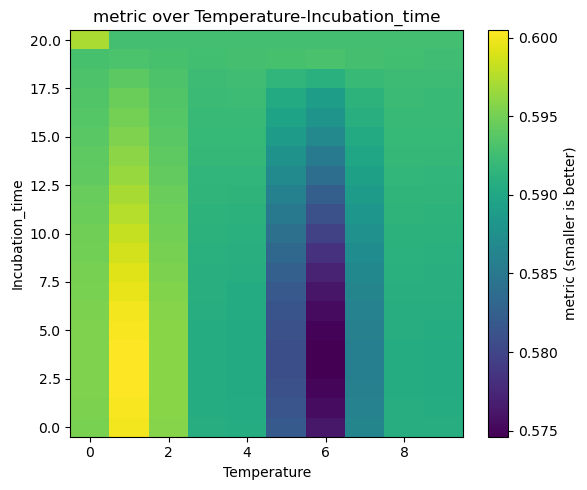

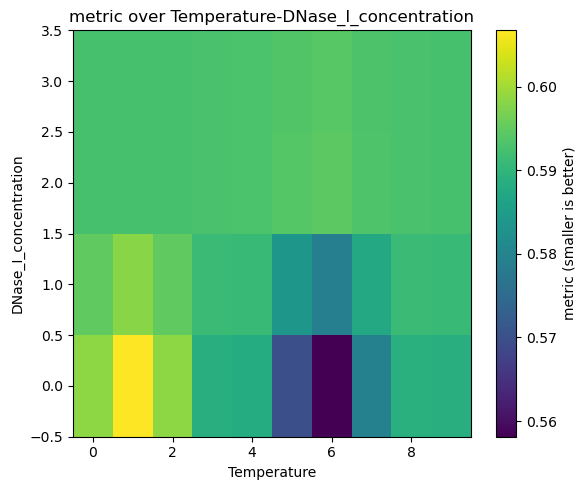

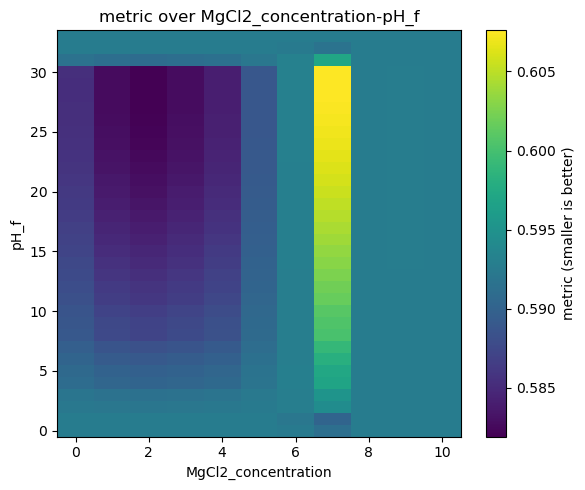

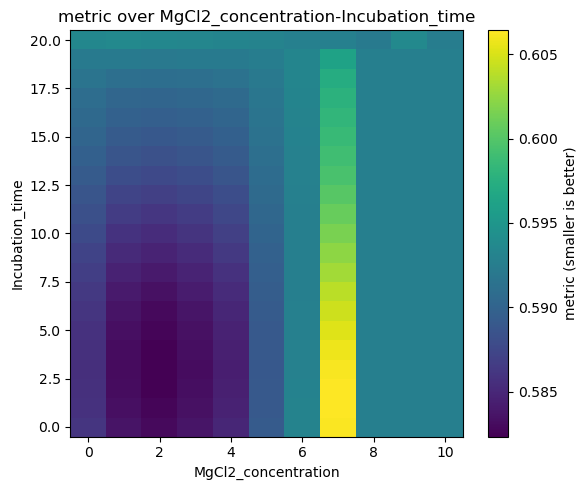

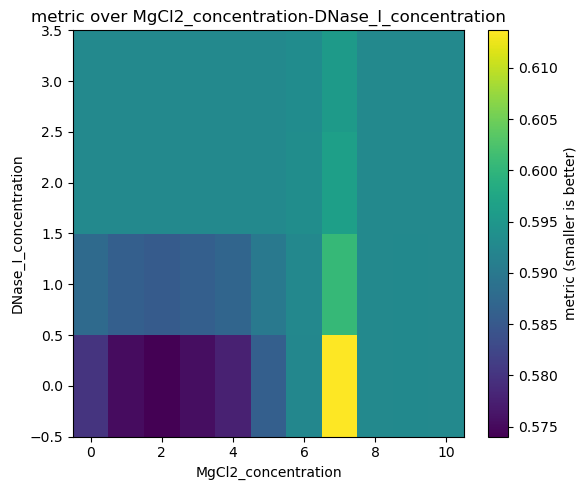

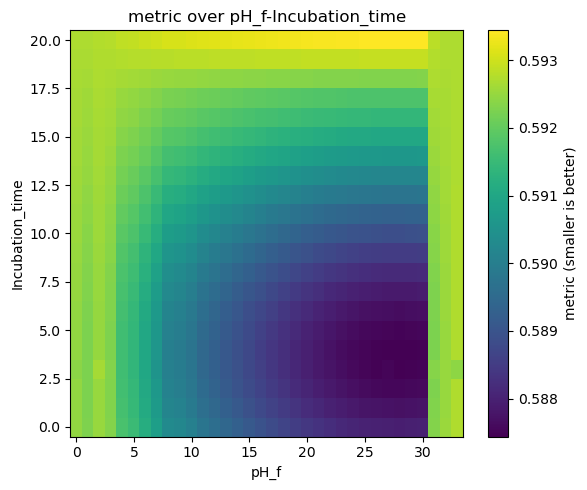

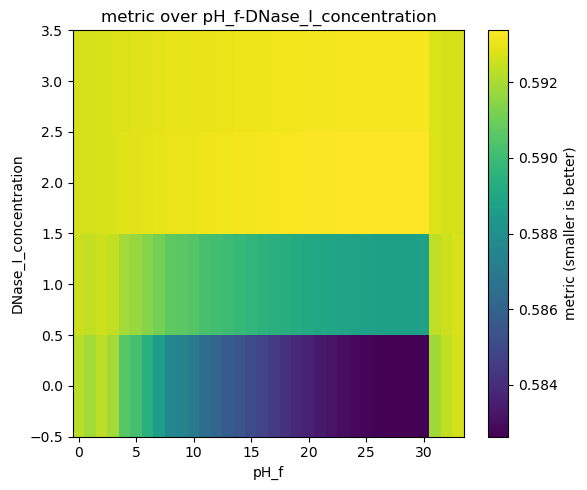

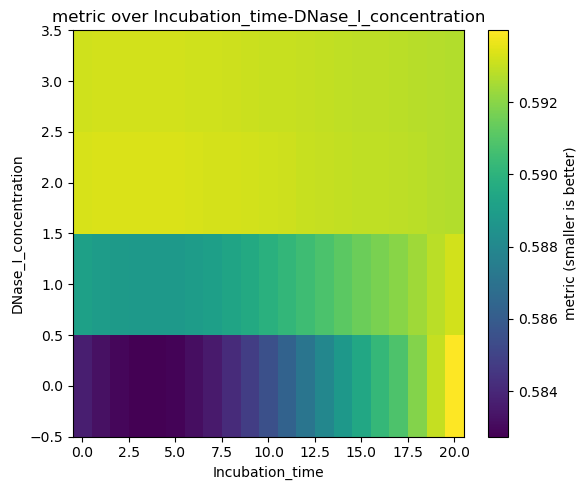

In [60]:
import itertools
features = ['Temperature','MgCl2_concentration','pH_f','Incubation_time','DNase_I_concentration']
for f1, f2 in itertools.combinations(features, 2):
    plot_heatmap_2d(df_Rods, f1, f2)

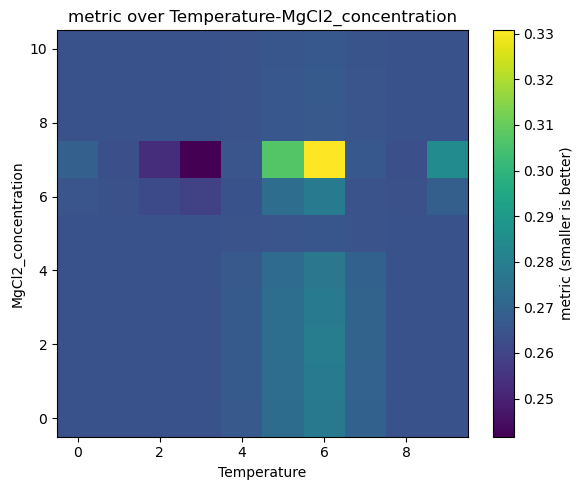

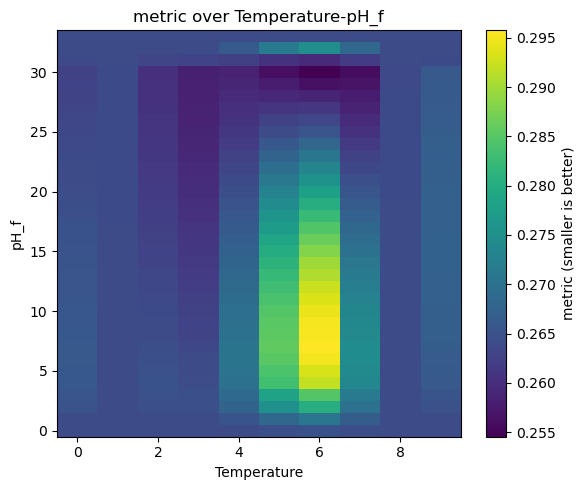

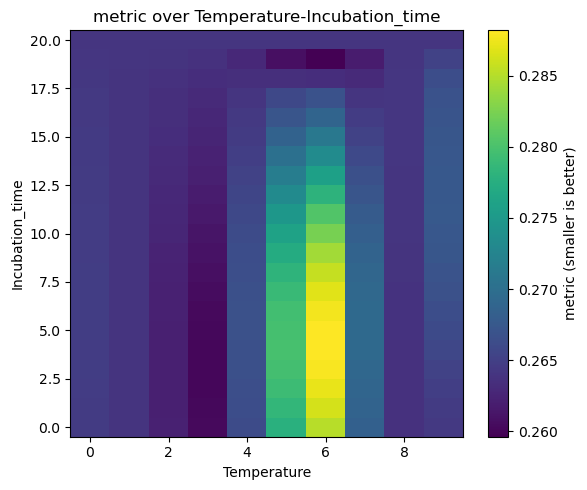

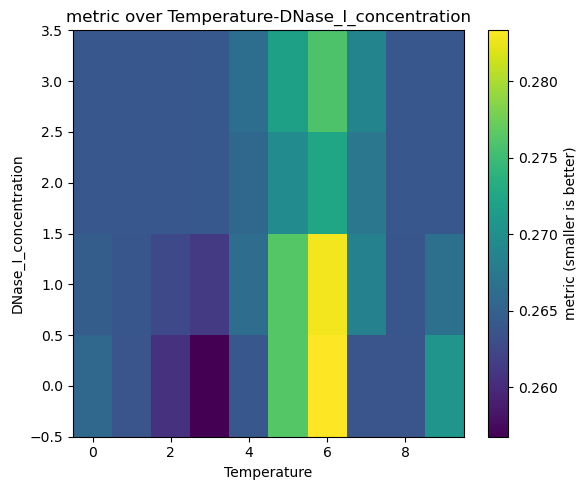

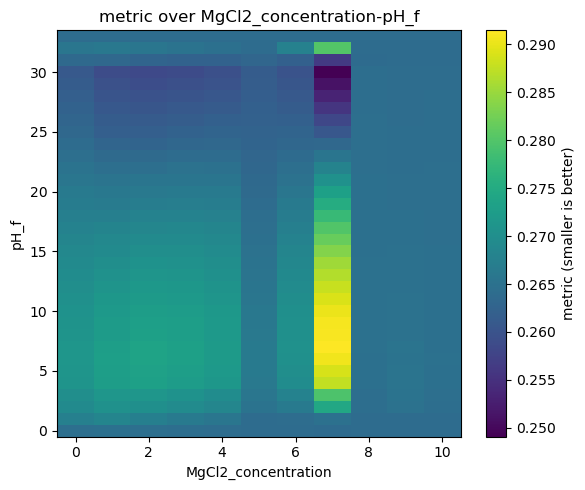

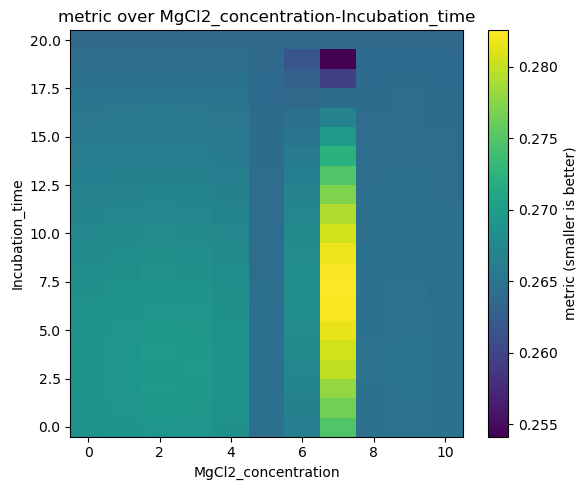

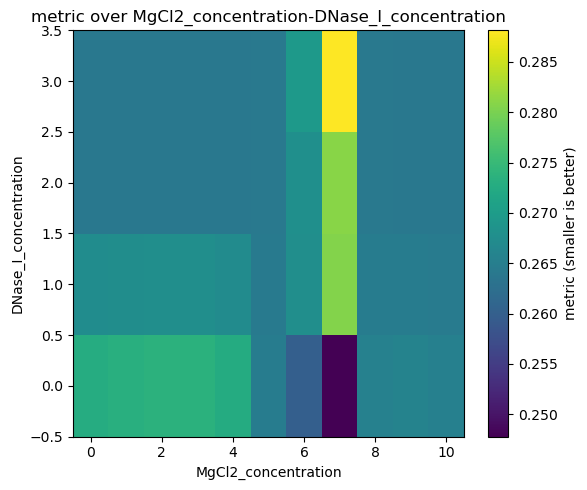

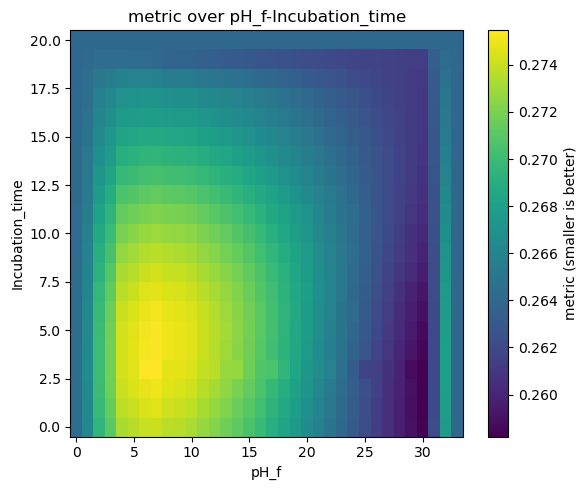

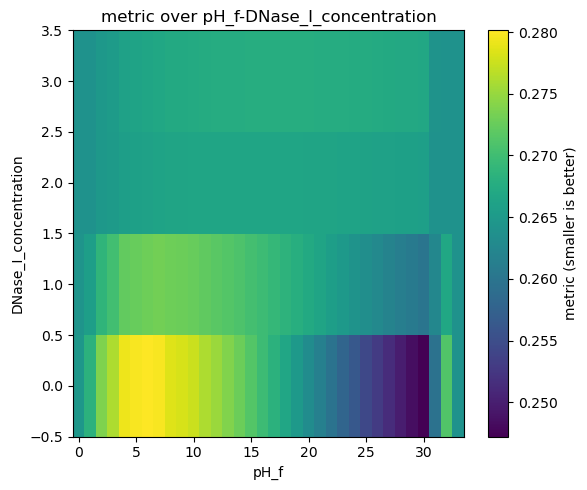

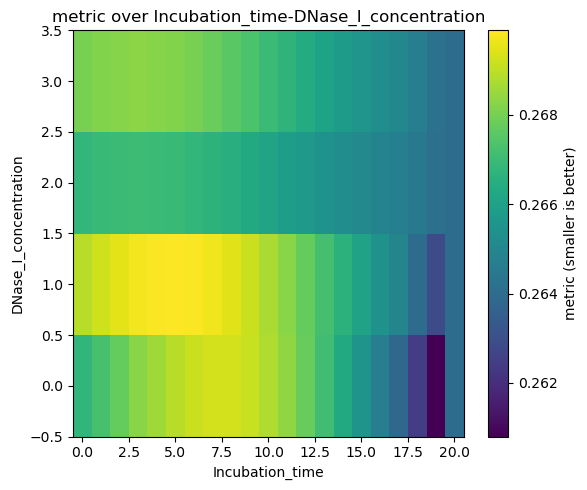

In [61]:
for f1, f2 in itertools.combinations(features, 2):
    plot_heatmap_2d(df_Spheres, f1, f2)

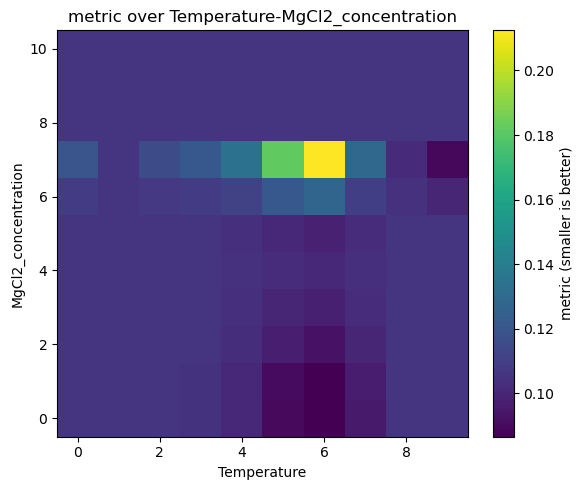

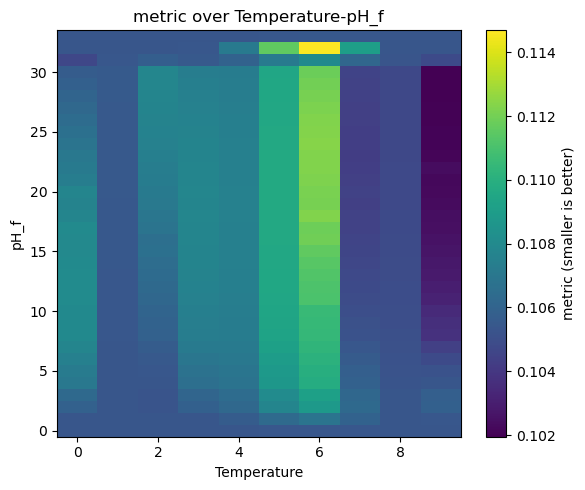

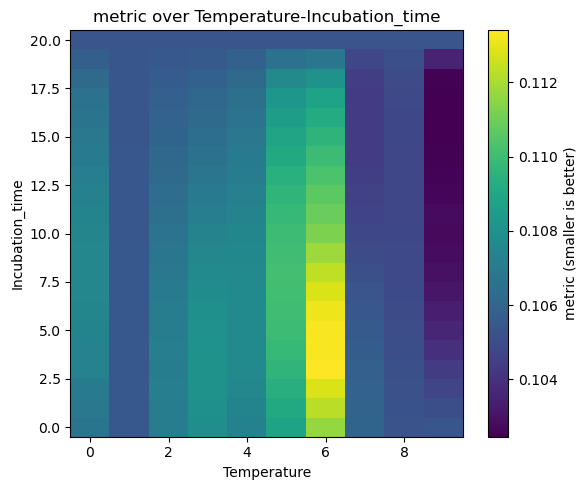

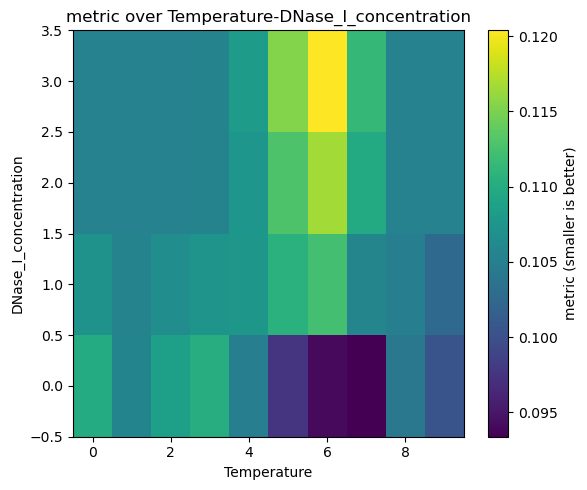

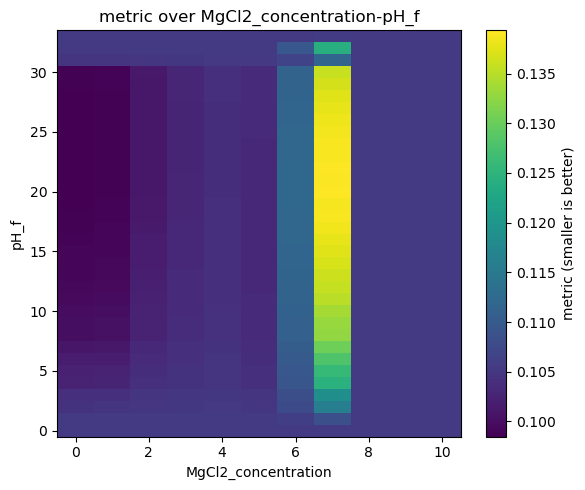

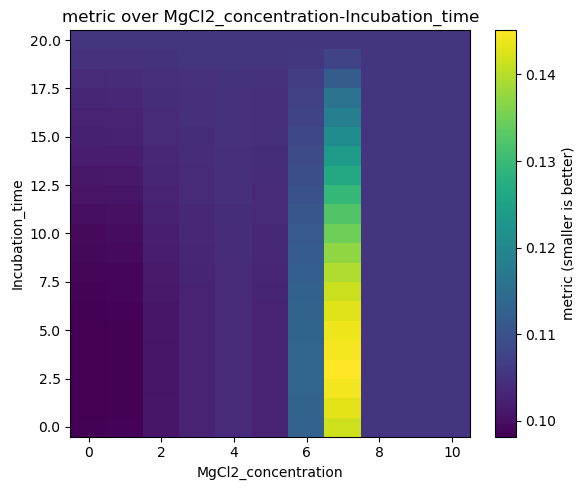

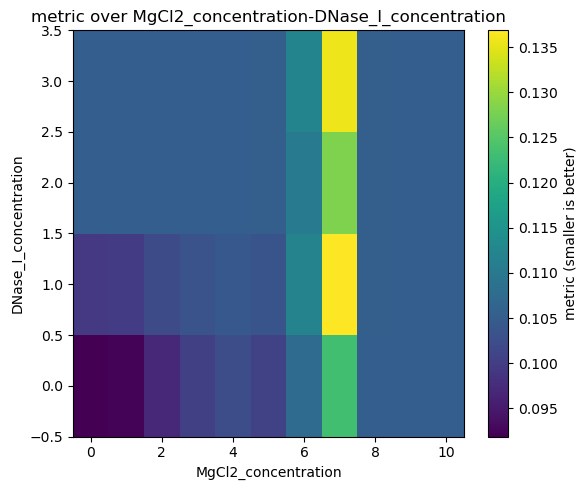

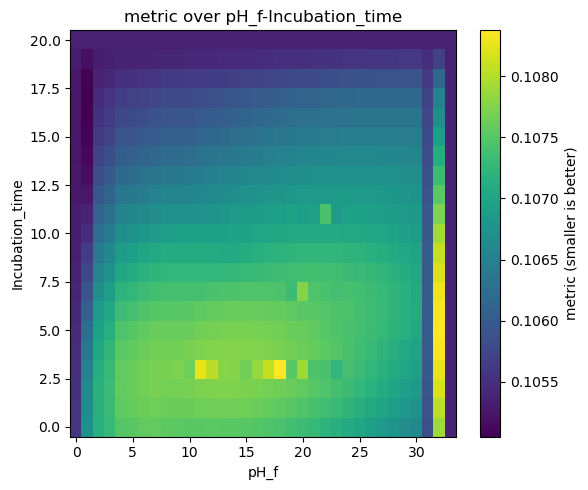

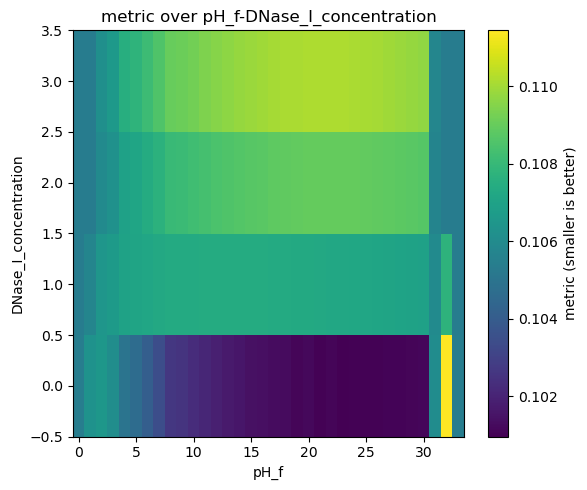

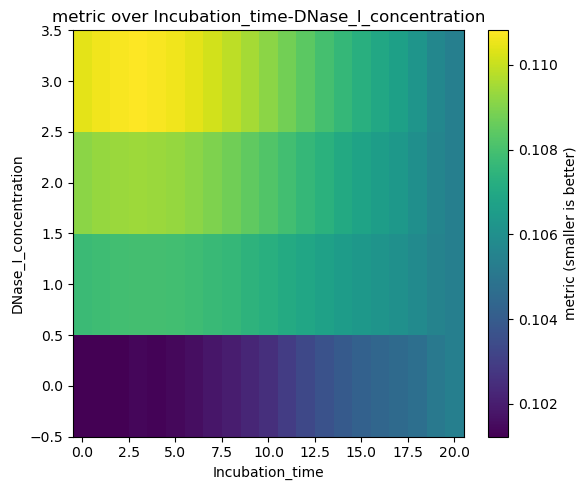

In [62]:
for f1, f2 in itertools.combinations(features, 2):
    plot_heatmap_2d(df_Rectangles, f1, f2)